In [1]:
import seaborn as sns
import csv
import time
import requests
from bs4 import BeautifulSoup

In [2]:
def normalizar_fecha_escrita(fecha_raw):
    return fecha_raw

urls = {
    "Vitoria": "https://www.booking.com/reviews/es/hotel/libere-vitoria-centro.es.html",
    "Donosti": "https://www.booking.com/reviews/es/hotel/koisi-hostel.es.html",
    "BilbaoMuseo": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-guggenheim.es.html",
    "BilbaoLaVieja": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-la-vieja.es.html",
    "ValenciaAbastos": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-abastos.es.html",
    "PamplonaYamaguchi": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-pamplona-yamaguchi.es.html",
    "ValenciaJardinBotanico": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-jardin-botanico.es.html",
    "MadridPalacioReal": "https://www.booking.com/reviews/es/hotel/libere-madrid-palacio-real.es.html",
    "MalagaTeatroRomano": "https://www.booking.com/reviews/es/hotel/apartamentosliberemalagateatroromano.es.html",
    "GranadaCatedral": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-granada-catedral.es.html",
    "MalagaLaMerced": "https://www.booking.com/reviews/es/hotel/libere-malaga-la-merced.es.html",
    "CordobaPatio": "https://www.booking.com/reviews/es/hotel/libere-cordoba-patio-santa-marta.es.html"}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "es-ES,es;q=0.9"}

with open("Datos/Transformados/comentarios.csv", mode="w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "ubicacion",
        "fecha",
        "puntuacion",
        "titulo_comentario",
        "comentario_negativo",
        "comentario_positivo",
        "etiquetas",
        "cantidad_comentarios",
        "nacionalidad"])

    for ubicacion, base_url in urls.items():
        print(f"\nScrapeando {ubicacion}")

        page = 1

        while True:
            print(f"  Página {page}")

            url = f"{base_url}?page={page}"
            response = requests.get(url, headers=headers)
            soup = BeautifulSoup(response.text, "html.parser")

            contenedor = soup.select("li.review_item.clearfix")

            if not contenedor:
                print("No hay mas")
                break

            for reseña in contenedor:

                fecha_el = reseña.select_one("p.review_item_date")
                fecha_raw = fecha_el.get_text(strip=True) if fecha_el else ""
                fecha = normalizar_fecha_escrita(fecha_raw)

                score = reseña.select_one("span.review-score-badge")
                puntuacion = score.get_text(strip=True) if score else ""

                titulo_el = reseña.select_one("span[itemprop='name']")
                titulo = titulo_el.get_text(strip=True) if titulo_el else ""

                neg = reseña.select_one("p.review_neg span[itemprop='reviewBody']")
                comentario_negativo = neg.get_text(strip=True) if neg else ""

                pos = reseña.select_one("p.review_pos span[itemprop='reviewBody']")
                comentario_positivo = pos.get_text(strip=True) if pos else ""

                etiquetas = reseña.select("ul.review_item_info_tags li")
                etiquetas_texto = " | ".join(
                    e.get_text(strip=True).replace("•", "").strip()
                    for e in etiquetas)

                com = reseña.select_one("div.review_item_user_review_count")
                comentarios_n = com.get_text(strip=True) if neg else ""

                nac = reseña.select_one("div.review_item_reviewer span[itemprop='nationality']")
                nacionalidad = nac.get_text(strip=True) if neg else ""

                writer.writerow([
                    ubicacion,
                    fecha,
                    puntuacion,
                    titulo,
                    comentario_negativo,
                    comentario_positivo,
                    etiquetas_texto,
                    comentarios_n,
                    nacionalidad
                ])
            page += 1
            time.sleep(1)


Scrapeando Vitoria
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
  Página 8
  Página 9
  Página 10
  Página 11
  Página 12
  Página 13
  Página 14
  Página 15
  Página 16
  Página 17
  Página 18
  Página 19
  Página 20
  Página 21
  Página 22
  Página 23
  Página 24
  Página 25
  Página 26
  Página 27
  Página 28
  Página 29
  Página 30
  Página 31
  Página 32
  Página 33
  Página 34
  Página 35
  Página 36
  Página 37
  Página 38
  Página 39
  Página 40
  Página 41
  Página 42
  Página 43
No hay mas

Scrapeando Donosti
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
  Página 8
  Página 9
  Página 10
  Página 11
  Página 12
  Página 13
  Página 14
  Página 15
  Página 16
  Página 17
  Página 18
No hay mas

Scrapeando BilbaoMuseo
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
No hay mas

Scrapeando BilbaoLaVieja
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
No hay mas

Scrapeando Valencia

Procesando Vitoria
Procesando Donosti
Procesando BilbaoMuseo
Procesando BilbaoLaVieja
Procesando ValenciaAbastos
Procesando PamplonaYamaguchi
Procesando ValenciaJardinBotanico
Procesando MadridPalacioReal
Procesando MalagaTeatroRomano
Procesando GranadaCatedral
Procesando MalagaLaMerced
Procesando CordobaPatio
 Donosti - Comentarios Negativos
   1. habitación      (56 veces)
   2. baño            (24 veces)
   3. camas           (17 veces)
   4. personal        (17 veces)
   5. llegar          (14 veces)
   6. bien            (14 veces)
   7. ducha           (13 veces)
   8. solo            (13 veces)
   9. habitaciones    (13 veces)
  10. cama            (12 veces)
  11. bastante        (12 veces)
  12. desayuno        (12 veces)
  13. noche           (11 veces)
  14. puerta          (11 veces)
  15. espacio         (11 veces)


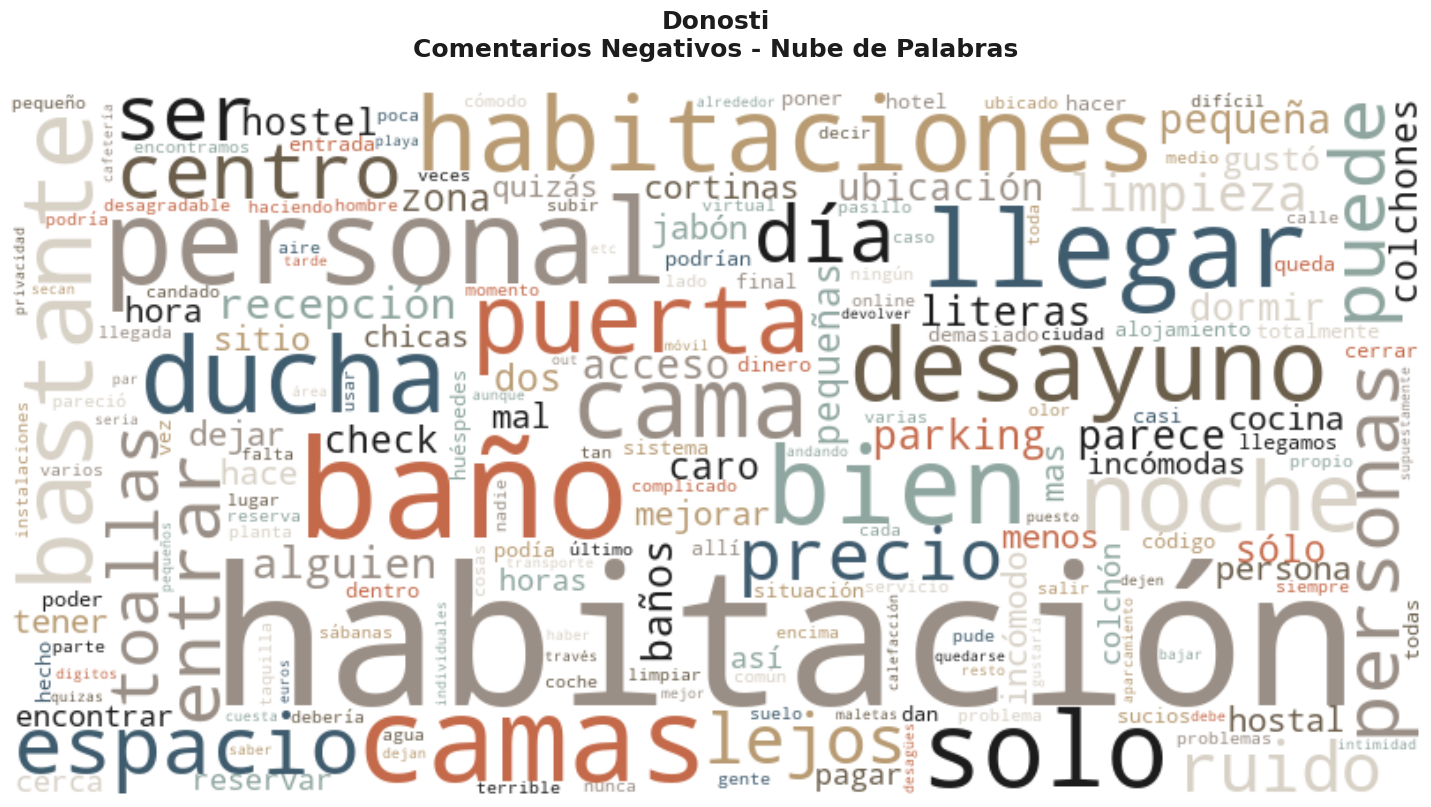

 PamplonaYamaguchi - Comentarios Negativos
   1. cama            (21 veces)
   2. baño            (16 veces)
   3. cocina          (13 veces)
   4. dos             (13 veces)
   5. sofá            (12 veces)
   6. solo            (12 veces)
   7. apartamento     (11 veces)
   8. personas        (10 veces)
   9. check           (10 veces)
  10. habitación      (10 veces)
  11. almohadas       (10 veces)
  12. escoba          (9 veces)
  13. parking         (8 veces)
  14. recepción       (8 veces)
  15. gustó           (8 veces)


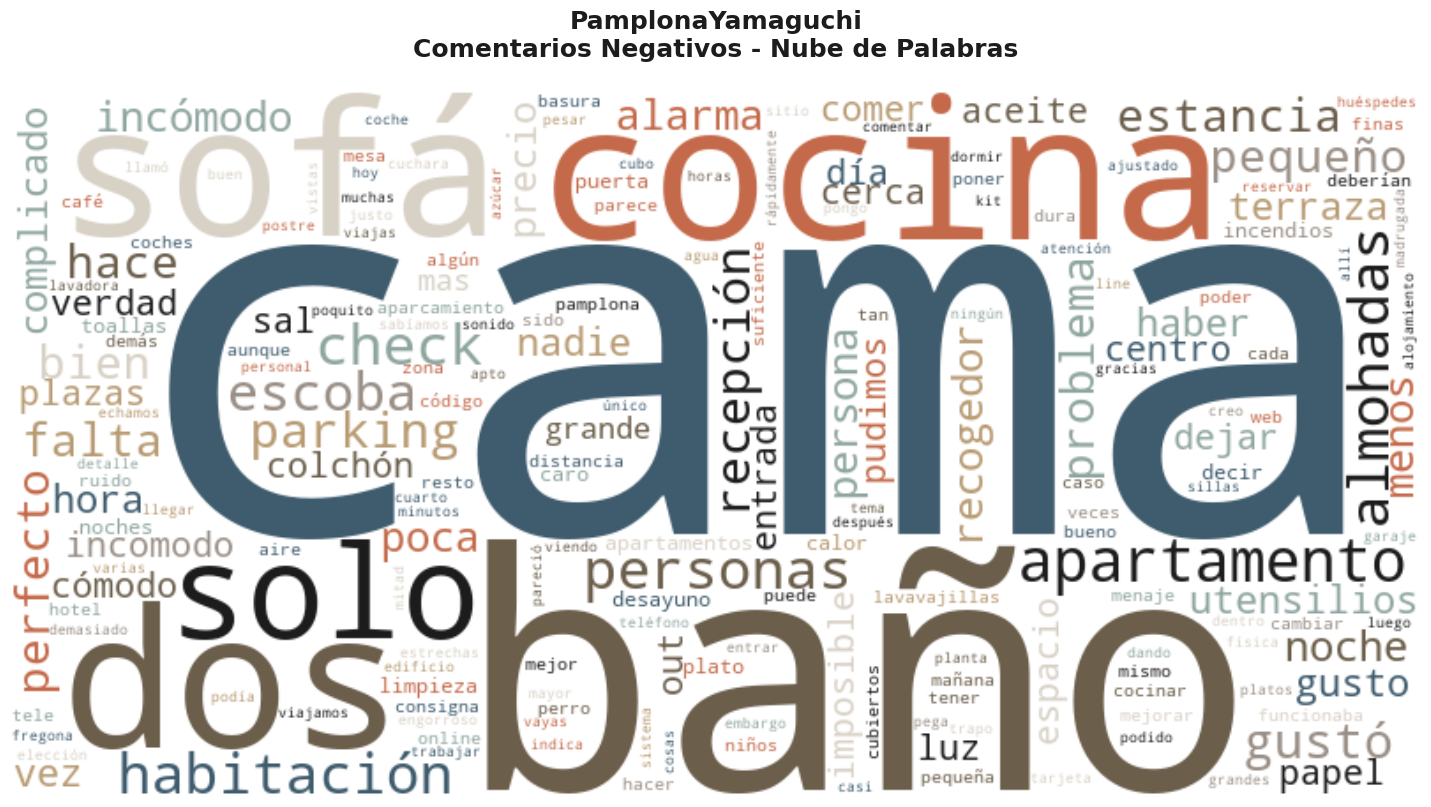

 Vitoria - Comentarios Negativos
   1. cama            (170 veces)
   2. sofá            (132 veces)
   3. apartamento     (57 veces)
   4. habitación      (56 veces)
   5. incómodo        (54 veces)
   6. bien            (48 veces)
   7. personal        (39 veces)
   8. check           (36 veces)
   9. limpieza        (35 veces)
  10. recepción       (34 veces)
  11. dormir          (29 veces)
  12. dos             (28 veces)
  13. falta           (28 veces)
  14. cómodo          (27 veces)
  15. personas        (25 veces)


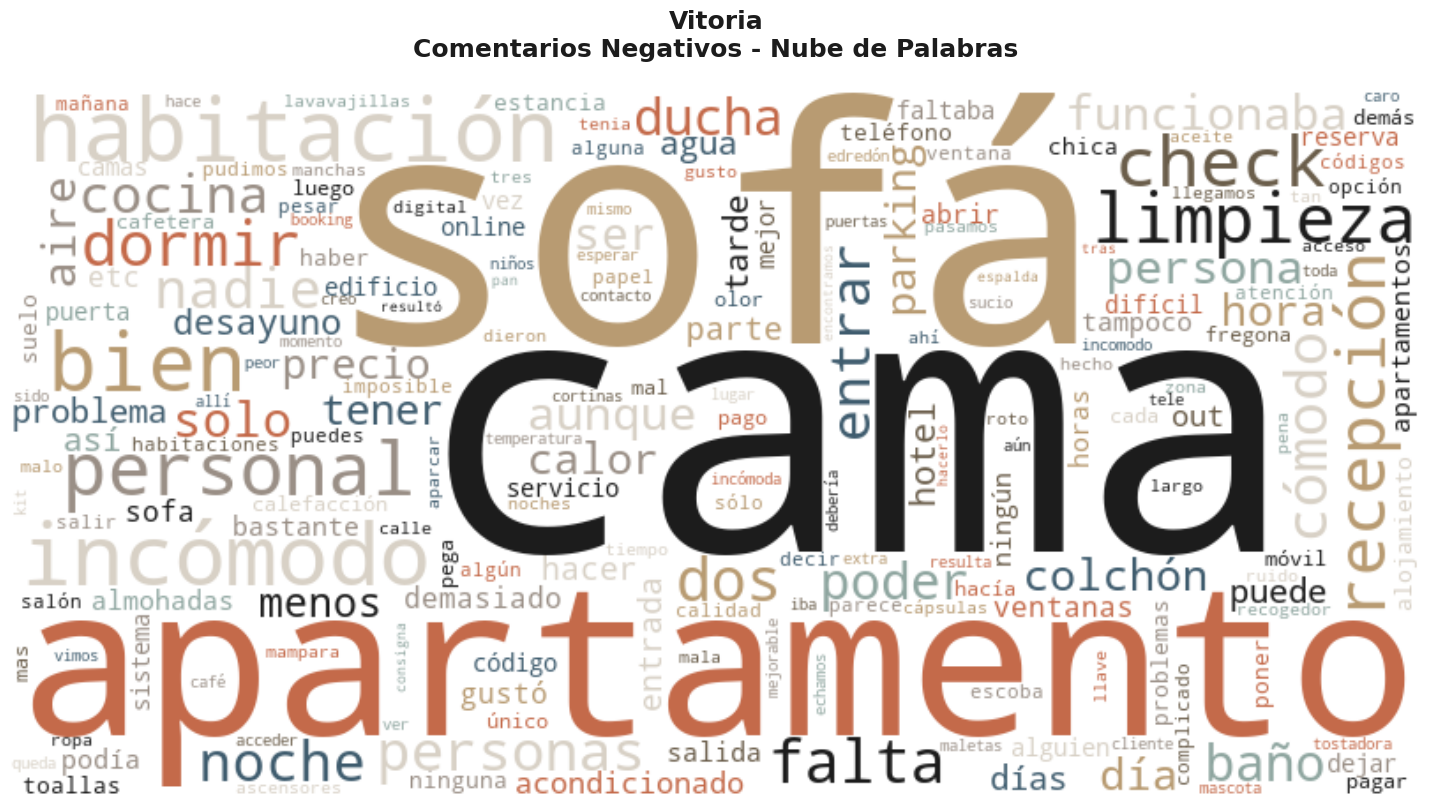

In [11]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import random

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

os.makedirs("Graficos/graficos_wordcloud", exist_ok=True)

df = pd.read_csv("Datos/Transformados/comentarios.csv", encoding="utf-8")

df["comentario_positivo"] = df["comentario_positivo"].fillna("")
df["comentario_negativo"] = df["comentario_negativo"].fillna("")

stop_words = set(stopwords.words("spanish"))

libere_true_graph_palette = [
    "#1C1C1C",
    "#6B5E4B",
    "#B89B72",
    "#3F5C6E",
    "#8FA6A0",
    "#C46A4A",
    "#9A8F86",
    "#D8D1C6"
]

def libere_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(libere_true_graph_palette)

def limpiar_texto(texto):
    texto = texto.lower()
    palabras = re.findall(r'\b\w+\b', texto)
    palabras_filtradas = [
        p for p in palabras
        if p not in stop_words and len(p) > 2
    ]
    return palabras_filtradas

hoteles_a_visualizar_neg = ["Donosti", "PamplonaYamaguchi", "Vitoria"]
graficos_temp = {}

hoteles = df["ubicacion"].unique()

for hotel in hoteles:
    print(f"Procesando {hotel}")
    
    df_hotel = df[df["ubicacion"] == hotel]
    
    texto_pos = " ".join(df_hotel["comentario_positivo"])
    palabras_pos = limpiar_texto(texto_pos)
    freq_pos = Counter(palabras_pos)
    
    if freq_pos:
        wordcloud_pos = WordCloud(
            width=800,
            height=400,
            background_color="#FFFFFF",
            color_func=libere_color_func
        ).generate_from_frequencies(freq_pos)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_pos, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{hotel} - Comentarios Positivos", color="#1C1C1C")
        plt.tight_layout()
        plt.savefig(f"Graficos/graficos_wordcloud/{hotel}_wordcloud_positivos.png", dpi=300)
        plt.close()
    
    texto_neg = " ".join(df_hotel["comentario_negativo"])
    palabras_neg = limpiar_texto(texto_neg)
    freq_neg = Counter(palabras_neg)
    
    if freq_neg:
        wordcloud_neg = WordCloud(
            width=800,
            height=400,
            background_color="#FFFFFF",
            color_func=libere_color_func
        ).generate_from_frequencies(freq_neg)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_neg, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{hotel} - Comentarios Negativos", color="#1C1C1C")
        plt.tight_layout()
        plt.savefig(f"Graficos/graficos_wordcloud/{hotel}_wordcloud_negativos.png", dpi=300)
        plt.close()
        
        if hotel in hoteles_a_visualizar_neg:
            graficos_temp[hotel] = (wordcloud_neg, freq_neg)


for hotel in hoteles_a_visualizar_neg:
    if hotel in graficos_temp:
        wordcloud, freq = graficos_temp[hotel]
        
        print(f" {hotel} - Comentarios Negativos")
        top_palabras = freq.most_common(15)
        for i, (palabra, frecuencia) in enumerate(top_palabras, 1):
            print(f"  {i:2d}. {palabra:15s} ({frecuencia} veces)")
        
        plt.figure(figsize=(15, 8))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{hotel}\nComentarios Negativos - Nube de Palabras", 
                 fontsize=18, pad=25, color="#1C1C1C", fontweight='bold')
        plt.tight_layout()
        plt.show()

Procesando análisis GLOBAL
Gráfico guardado: Vitoria
Gráfico guardado: Donosti
Gráfico guardado: BilbaoMuseo
Gráfico guardado: BilbaoLaVieja
Gráfico guardado: ValenciaAbastos
Gráfico guardado: PamplonaYamaguchi
Gráfico guardado: ValenciaJardinBotanico
Gráfico guardado: MadridPalacioReal
Gráfico guardado: MalagaTeatroRomano
Gráfico guardado: GranadaCatedral
Gráfico guardado: MalagaLaMerced
Gráfico guardado: CordobaPatio

Visualizando Vitoria:


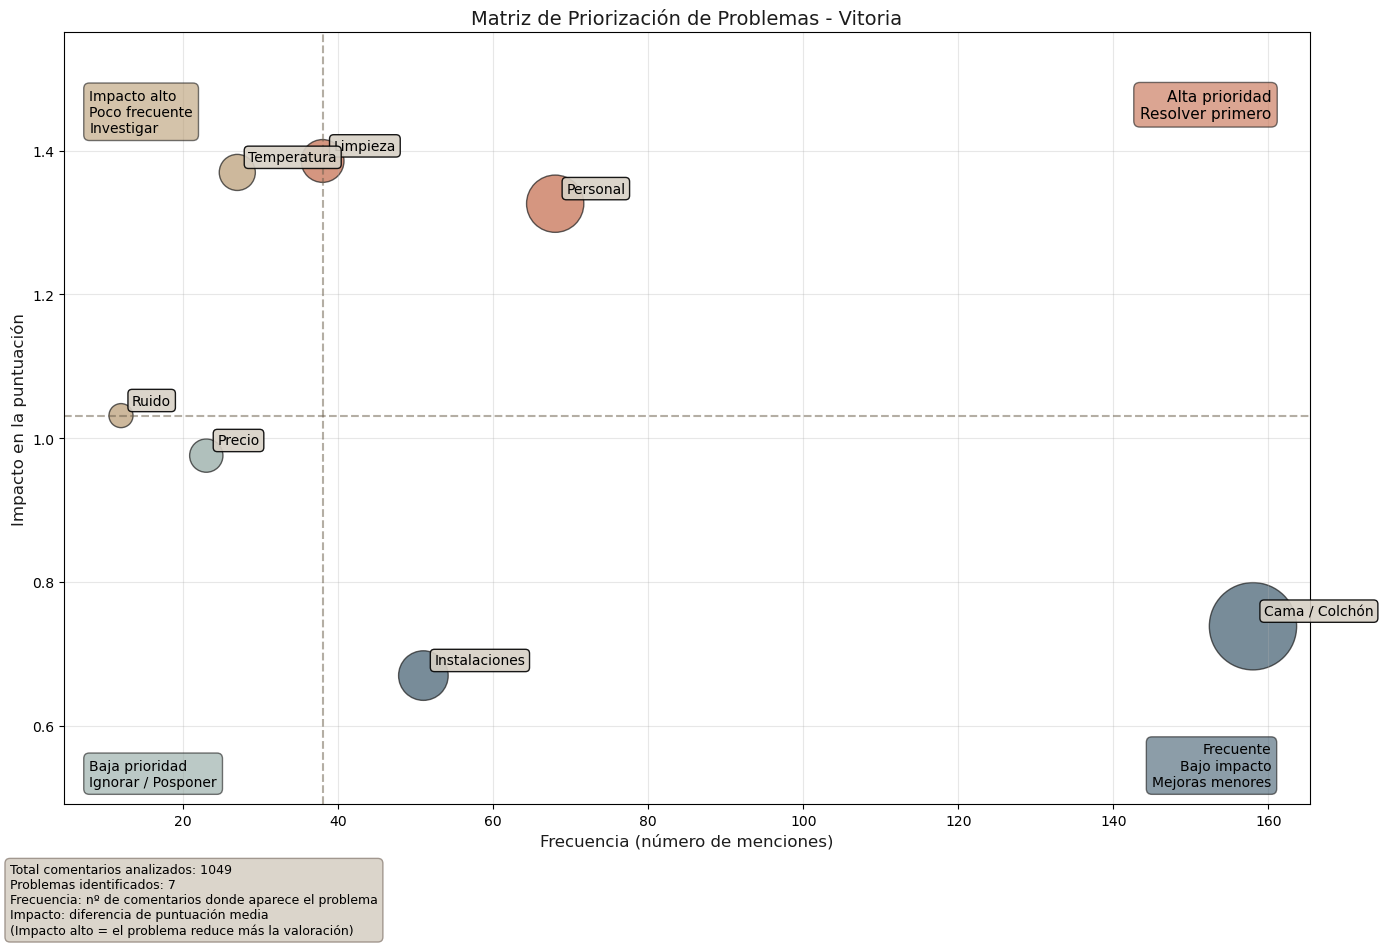


Visualizando Donosti:


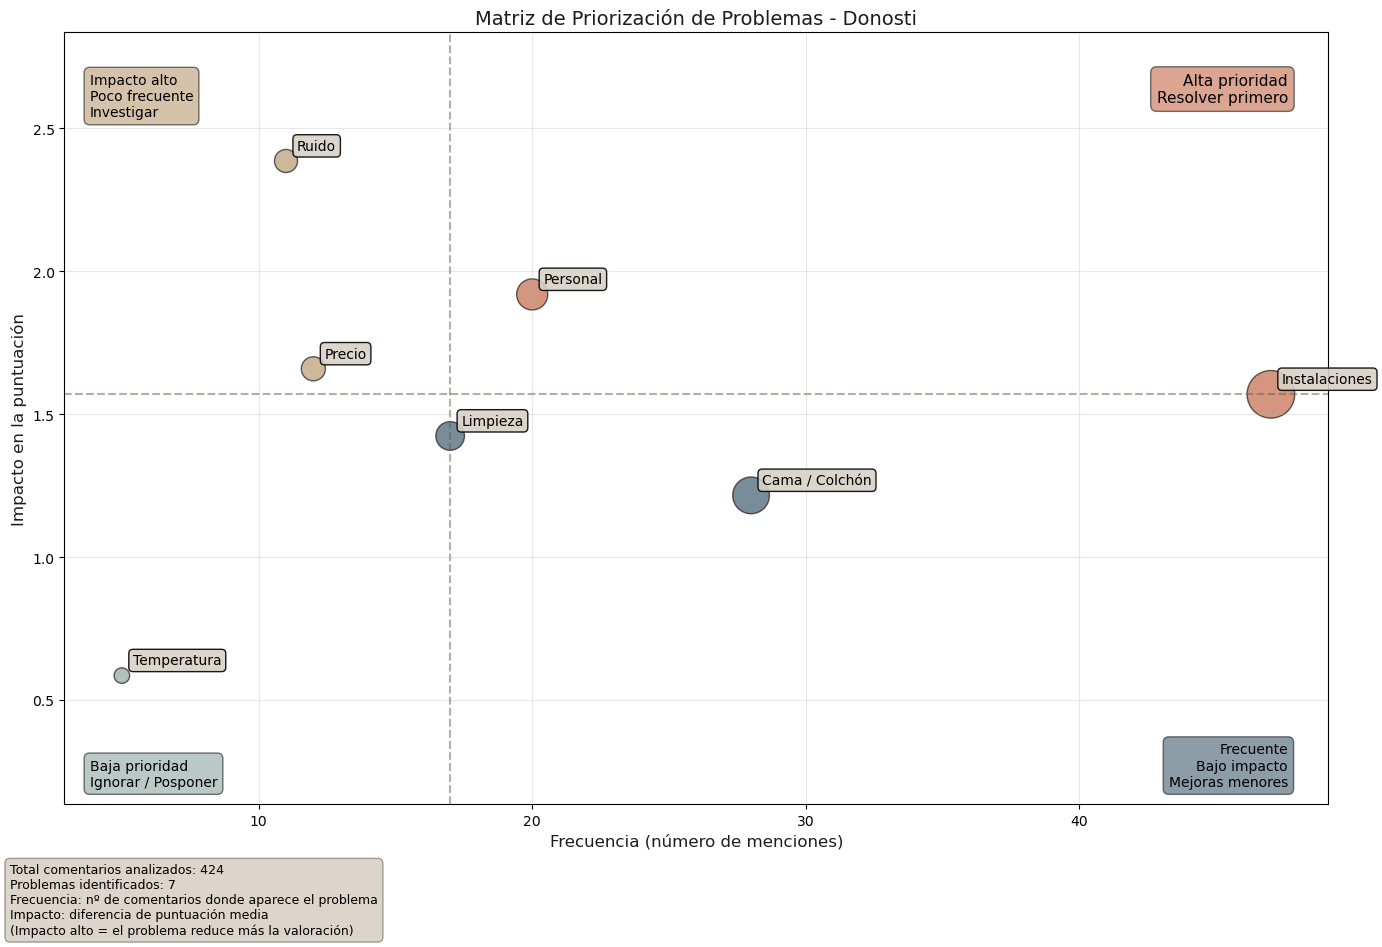


Visualizando PamplonaYamaguchi:


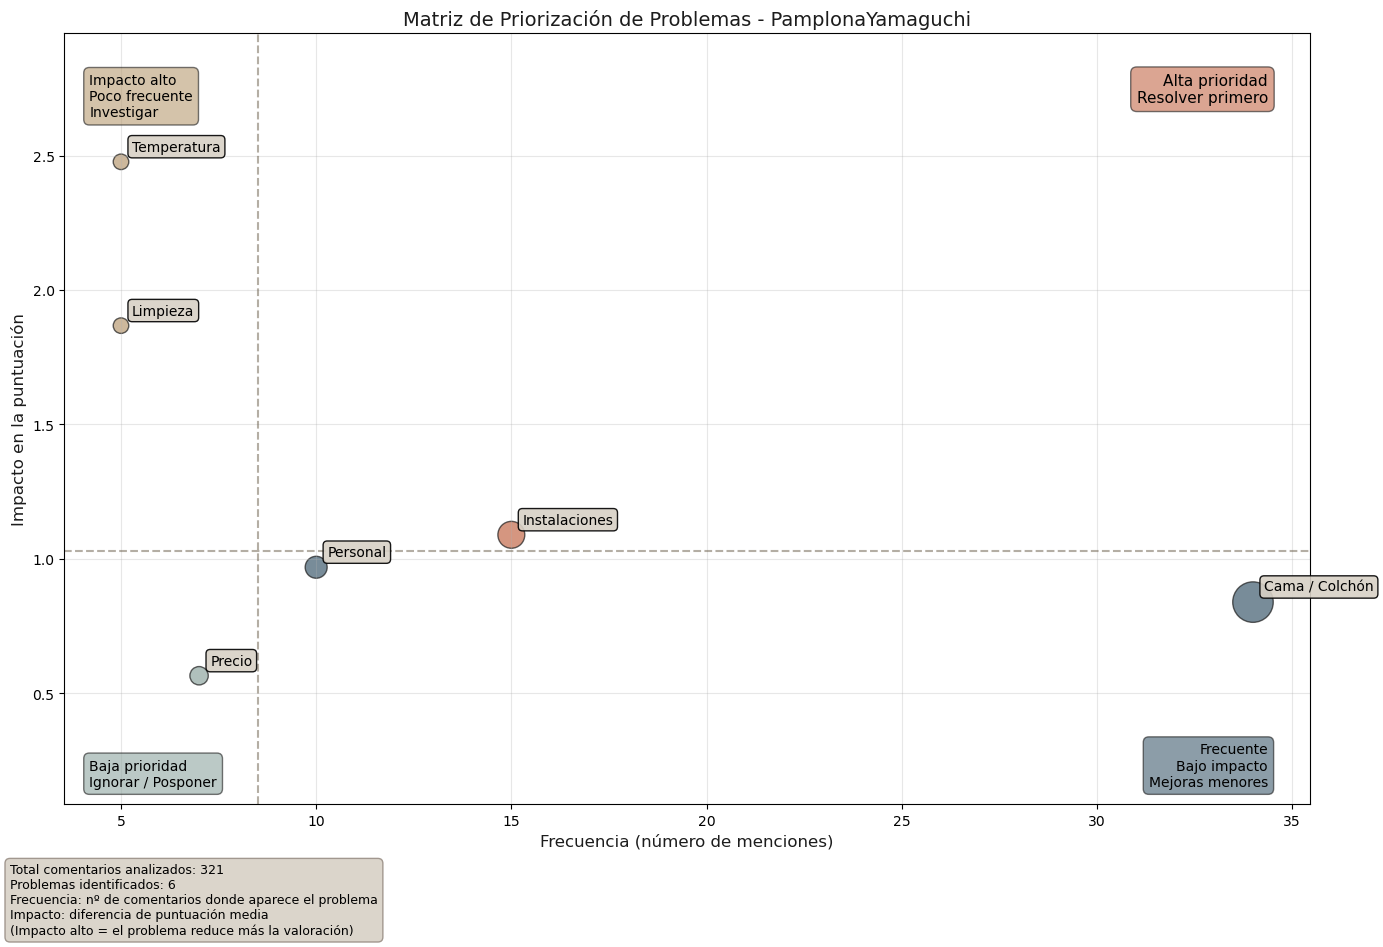

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("Graficos/graficos_prioridad", exist_ok=True)

df = pd.read_csv("Datos/Transformados/comentarios.csv", encoding="utf-8")

df["puntuacion"] = (
    df["puntuacion"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["comentario_negativo"] = df["comentario_negativo"].fillna("")

problemas_clave = {
    "Limpieza": ["sucio", "sucia", "limpieza", "limpio"],
    "Ruido": ["ruido", "ruidoso", "ruidos"],
    "Cama / Colchón": ["cama", "colchón", "almohada"],
    "Temperatura": ["frío", "fria", "calor", "aire"],
    "Instalaciones": ["baño", "ducha", "habitacion", "habitaciones"],
    "Precio": ["caro", "precio", "coste"],
    "Personal": ["personal", "trato", "recepción"]
}

def contiene_problema(texto, palabras):
    texto = texto.lower()
    return any(p in texto for p in palabras)

def generar_matriz(df_base, titulo, nombre_archivo, mostrar=False):
    resultados = []
    for problema, palabras in problemas_clave.items():
        mask = df_base["comentario_negativo"].apply(
            lambda x: contiene_problema(x, palabras)
        )
        df_con = df_base[mask]
        df_sin = df_base[~mask]
        
        if len(df_con) < 5 or len(df_sin) < 5:
            continue
            
        impacto = df_sin["puntuacion"].mean() - df_con["puntuacion"].mean()
        resultados.append({
            "problema": problema,
            "frecuencia": len(df_con),
            "impacto": impacto
        })
    
    if not resultados:
        return None
    
    df_prioridad = pd.DataFrame(resultados)
    
    mediana_frec = df_prioridad["frecuencia"].median()
    mediana_imp = df_prioridad["impacto"].median()
    
    colores = []
    for _, row in df_prioridad.iterrows():
        if row["frecuencia"] >= mediana_frec and row["impacto"] >= mediana_imp:
            colores.append("#C46A4A")  
        elif row["frecuencia"] < mediana_frec and row["impacto"] >= mediana_imp:
            colores.append("#B89B72")  
        elif row["frecuencia"] >= mediana_frec and row["impacto"] < mediana_imp:
            colores.append("#3F5C6E")  
        else:
            colores.append("#8FA6A0") 
    
    if mostrar:
        plt.figure(figsize=(14, 10))
    else:
        plt.figure(figsize=(14, 10))
    
    plt.scatter(
        df_prioridad["frecuencia"],
        df_prioridad["impacto"],
        s=df_prioridad["frecuencia"] * 25,
        c=colores,
        alpha=0.7,
        edgecolors="#1C1C1C"
    )
    
    for _, row in df_prioridad.iterrows():
        plt.annotate(
            row["problema"],
            (row["frecuencia"], row["impacto"]),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#D8D1C6", alpha=0.9)
        )
    
    y_min = df_prioridad["impacto"].min()
    y_max = df_prioridad["impacto"].max()
    margen_y = (y_max - y_min) * 0.25 if y_max != y_min else 0.5
    plt.ylim(y_min - margen_y, y_max + margen_y)
    
    plt.axvline(mediana_frec, linestyle="--", alpha=0.5, color="#6B5E4B")
    plt.axhline(mediana_imp, linestyle="--", alpha=0.5, color="#6B5E4B")
    
    plt.xlabel("Frecuencia (número de menciones)", color="#1C1C1C", fontsize=12)
    plt.ylabel("Impacto en la puntuación", color="#1C1C1C", fontsize=12)
    
    plt.title(titulo, color="#1C1C1C", fontsize=14)
    
    plt.grid(True, alpha=0.3)
    
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    
    plt.text(
        x_max * 0.97,
        y_max * 0.95,
        "Alta prioridad\nResolver primero",
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#C46A4A", alpha=0.6, edgecolor="#1C1C1C")
    )
    
    plt.text(
        x_min + (x_max - x_min) * 0.02,
        y_max * 0.95,
        "Impacto alto\nPoco frecuente\nInvestigar",
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#B89B72", alpha=0.6, edgecolor="#1C1C1C")
    )
    
    plt.text(
        x_max * 0.97,
        y_min + (y_max - y_min) * 0.02,
        "Frecuente\nBajo impacto\nMejoras menores",
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#3F5C6E", alpha=0.6, edgecolor="#1C1C1C")
    )
    
    plt.text(
        x_min + (x_max - x_min) * 0.02,
        y_min + (y_max - y_min) * 0.02,
        "Baja prioridad\nIgnorar / Posponer",
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#8FA6A0", alpha=0.6, edgecolor="#1C1C1C")
    )
    
    nota = (
        f"Total comentarios analizados: {len(df_base)}\n"
        f"Problemas identificados: {len(resultados)}\n"
        f"Frecuencia: nº de comentarios donde aparece el problema\n"
        f"Impacto: diferencia de puntuación media\n"
        f"(Impacto alto = el problema reduce más la valoración)"
    )
    
    plt.figtext(
        0.01,
        0.01,
        nota,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#D8D1C6", alpha=0.9, edgecolor="#9A8F86")
    )
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    
    plt.savefig(f"Graficos/graficos_prioridad/{nombre_archivo}", dpi=300, bbox_inches='tight')
    
    if mostrar:
        plt.show()
        return None  # No retornar DataFrame cuando se muestra el gráfico
    else:
        plt.close()
        return df_prioridad  # Solo retornar DataFrame cuando no se muestra

print("Procesando análisis GLOBAL")
generar_matriz(
    df,
    "Matriz de Priorización de Problemas - ANÁLISIS GLOBAL",
    "GLOBAL_matriz_prioridad.png",
    mostrar=False
)

hoteles = df["ubicacion"].unique()

for hotel in hoteles:
    df_hotel = df[df["ubicacion"] == hotel]
    
    generar_matriz(
        df_hotel,
        f"Matriz de Priorización de Problemas - {hotel}",
        f"{hotel}_matriz_prioridad.png",
        mostrar=False
    )
    
    print(f"Gráfico guardado: {hotel}")

print("\nVisualizando Vitoria:")
df_vitoria = df[df["ubicacion"] == "Vitoria"]
_ = generar_matriz(
    df_vitoria,
    "Matriz de Priorización de Problemas - Vitoria",
    "temp_vitoria.png",  
    mostrar=True
)

print("\nVisualizando Donosti:")
df_donosti = df[df["ubicacion"] == "Donosti"]
_ = generar_matriz(
    df_donosti,
    "Matriz de Priorización de Problemas - Donosti",
    "temp_donosti.png",  
    mostrar=True
)

print("\nVisualizando PamplonaYamaguchi:")
df_pamplona = df[df["ubicacion"] == "PamplonaYamaguchi"]
_ = generar_matriz(
    df_pamplona,
    "Matriz de Priorización de Problemas - PamplonaYamaguchi",
    "temp_pamplona.png",  
    mostrar=True
)

C:\Users\sebas\AppData\Local\Temp\ipykernel_21292\3773396834.py:69: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trimestral = evolucion.resample("Q").mean()


Gráfico guardado: Vitoria


C:\Users\sebas\AppData\Local\Temp\ipykernel_21292\3773396834.py:69: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trimestral = evolucion.resample("Q").mean()


Gráfico guardado: Donosti


C:\Users\sebas\AppData\Local\Temp\ipykernel_21292\3773396834.py:69: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trimestral = evolucion.resample("Q").mean()


...

Gráfico guardado: MalagaTeatroRomano


C:\Users\sebas\AppData\Local\Temp\ipykernel_21292\3773396834.py:69: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trimestral = evolucion.resample("Q").mean()


Gráfico guardado: GranadaCatedral


C:\Users\sebas\AppData\Local\Temp\ipykernel_21292\3773396834.py:69: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  trimestral = evolucion.resample("Q").mean()


Gráfico guardado: CordobaPatio


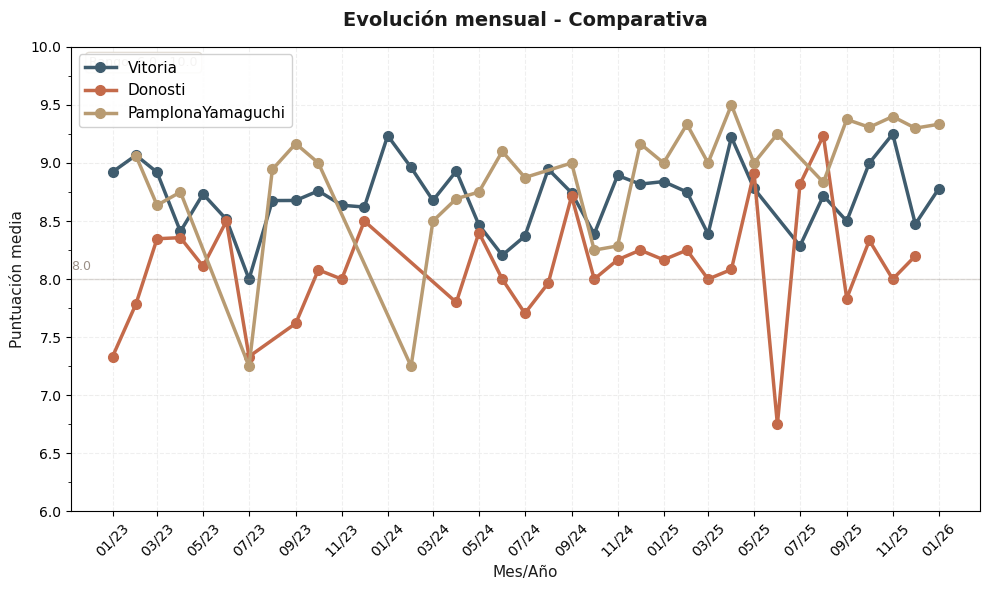

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import re

os.makedirs("Graficos", exist_ok=True)
os.makedirs("Graficos/evolucion_mensual", exist_ok=True)

df = pd.read_csv("Datos/Transformados/comentarios.csv", encoding="utf-8")

df["puntuacion"] = (
    df["puntuacion"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df["puntuacion"] = pd.to_numeric(df["puntuacion"], errors="coerce")
df = df[(df["puntuacion"] >= 5) & (df["puntuacion"] <= 10)]

LIBERE = {
    "negro": "#1C1C1C",
    "arena": "#B89B72",
    "azul": "#3F5C6E",
    "verde": "#8FA6A0",
    "terracota": "#C46A4A",
    "gris_claro": "#D8D1C6",
    "gris_medio": "#9A8F86"
}

MESES = {
    "enero": "01", "febrero": "02", "marzo": "03",
    "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08",
    "septiembre": "09", "octubre": "10",
    "noviembre": "11", "diciembre": "12"
}

def convertir_fecha(fecha):
    if pd.isna(fecha):
        return None
    fecha = str(fecha).lower().replace("escrito en ", "")
    m = re.search(r"(\d{1,2}) de (\w+) de (\d{4})", fecha)
    if not m:
        return None
    dia, mes_txt, anio = m.groups()
    if mes_txt not in MESES:
        return None
    return pd.to_datetime(f"{anio}-{MESES[mes_txt]}-{dia}")

df["fecha_dt"] = df["fecha"].apply(convertir_fecha)
df = df.dropna(subset=["fecha_dt", "puntuacion"])
df["mes"] = df["fecha_dt"].dt.to_period("M").dt.to_timestamp()

for hotel in df["ubicacion"].unique():

    df_h = df[df["ubicacion"] == hotel]

    resumen = (
        df_h.groupby("mes")
        .agg(media=("puntuacion", "mean"), n=("puntuacion", "count"))
        .sort_index()
    )

    resumen = resumen[resumen["n"] >= 3]
    if len(resumen) < 4:
        continue

    evolucion = resumen["media"]
    trimestral = evolucion.resample("Q").mean()

    mayor_subida = None
    mayor_bajada = None

    for i in range(3, len(evolucion)):
        media_prev = evolucion.iloc[i-3:i].mean()
        actual = evolucion.iloc[i]
        diff = actual - media_prev

        if diff > 0:
            if mayor_subida is None or diff > mayor_subida[2]:
                mayor_subida = (evolucion.index[i], actual, diff)
        else:
            if mayor_bajada is None or diff < mayor_bajada[2]:
                mayor_bajada = (evolucion.index[i], actual, diff)

    plt.figure(figsize=(11, 5))

    plt.plot(
        evolucion.index,
        evolucion.values,
        marker="o",
        linewidth=2.5,
        color=LIBERE["azul"],
        label="Media mensual"
    )

    plt.plot(
        trimestral.index,
        trimestral.values,
        linestyle="--",
        linewidth=2,
        color=LIBERE["arena"],
        label="Media trimestral"
    )

    if mayor_subida:
        mes, valor, diff = mayor_subida
        plt.scatter(mes, valor, s=160, marker="^", color=LIBERE["verde"])
        plt.annotate(
            f"Subida +{diff:.2f}",
            (mes, valor),
            xytext=(10, 15),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color=LIBERE["verde"]),
            fontsize=9
        )

    if mayor_bajada:
        mes, valor, diff = mayor_bajada
        plt.scatter(mes, valor, s=160, marker="X", color=LIBERE["terracota"])
        plt.annotate(
            f"Bajada {diff:.2f}",
            (mes, valor),
            xytext=(10, -30),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color=LIBERE["terracota"]),
            fontsize=9
        )

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    plt.title(f"Evolución mensual – {hotel}", color=LIBERE["negro"])
    plt.xlabel("Mes", color=LIBERE["negro"])
    plt.ylabel("Puntuación media", color=LIBERE["negro"])
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"Graficos/evolucion_mensual/{hotel}_evolucion_mensual.png",
        dpi=300
    )
    plt.close()
    print(f"Gráfico guardado: {hotel}")

hoteles_objetivo = ["Vitoria", "Donosti", "PamplonaYamaguchi"]
colores_hoteles = [
    LIBERE["azul"],
    LIBERE["terracota"],
    LIBERE["arena"]
]

plt.figure(figsize=(10, 6))  

lineas_por_hotel = {}  

for hotel, color in zip(hoteles_objetivo, colores_hoteles):

    df_h = df[df["ubicacion"] == hotel]

    resumen = (
        df_h.groupby("mes")
        .agg(media=("puntuacion", "mean"), n=("puntuacion", "count"))
        .sort_index()
    )
    
    resumen = resumen[resumen["n"] >= 3]
    
    if len(resumen) < 2:
        print(f"Datos insuficientes para {hotel}")
        continue

    line, = plt.plot(
        resumen.index,
        resumen["media"],
        marker="o",
        linewidth=2.5,  
        color=color,
        label=hotel,
        markersize=7
    )
    
    lineas_por_hotel[hotel] = line

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y")) 
plt.xticks(rotation=45, fontsize=10)

plt.title(
    "Evolución mensual - Comparativa",
    color=LIBERE["negro"],
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel("Mes/Año", color=LIBERE["negro"], fontsize=11)
plt.ylabel("Puntuación media", color=LIBERE["negro"], fontsize=11)

plt.ylim(6, 10)

ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))

plt.grid(alpha=0.2, linestyle='--')

plt.legend(loc='upper left', fontsize=11, framealpha=0.9)

for y_val in [6.0, 7.0, 8.0, 9.0, 10.0]:
    if y_val == 8.0:
        plt.axhline(y=y_val, color=LIBERE["gris_medio"], linestyle='-', alpha=0.3, linewidth=1)
        plt.text(plt.xlim()[0] + 0.01, y_val + 0.05, "8.0", 
                color=LIBERE["gris_medio"], fontsize=9, verticalalignment='bottom')
    else:
        plt.axhline(y=y_val, color=LIBERE["gris_claro"], linestyle=':', alpha=0.2, linewidth=0.5)

plt.text(0.02, 0.98, "Rango: 6.0 - 10.0", 
         transform=ax.transAxes,
         color=LIBERE["gris_medio"],
         fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor=LIBERE["gris_claro"]))

plt.tight_layout()

plt.savefig(
    "Graficos/evolucion_mensual/comparativa_3_hoteles.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

  1. Vitoria: 1049 comentarios
  2. CordobaPatio: 492 comentarios
  3. Donosti: 424 comentarios
  4. PamplonaYamaguchi: 321 comentarios
  5. BilbaoLaVieja: 149 comentarios


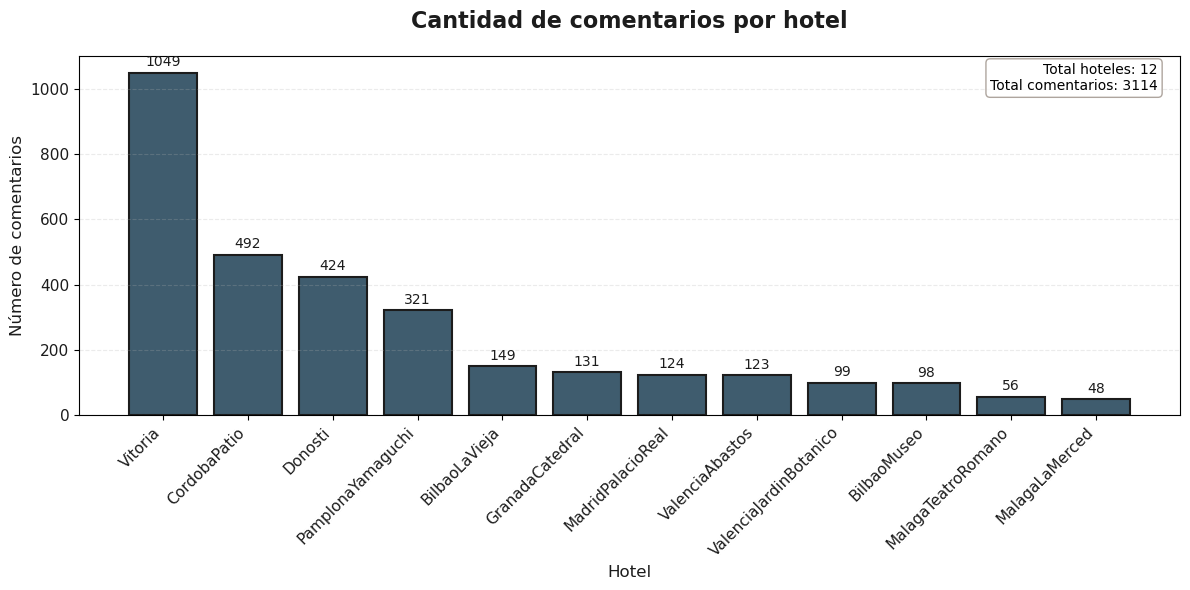

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("Graficos", exist_ok=True)

df = pd.read_csv("Datos/Transformados/comentarios.csv", encoding="utf-8")

LIBERE = {
    "negro": "#1C1C1C",
    "azul": "#3F5C6E",
    "terracota": "#C46A4A",
    "gris_medio": "#9A8F86"
}

conteo = (
    df.groupby("ubicacion")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    conteo.index,
    conteo.values,
    color=LIBERE["azul"],
    edgecolor=LIBERE["negro"],
    linewidth=1.5
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (conteo.max() * 0.01),
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        color=LIBERE["negro"]
    )

plt.title(
    "Cantidad de comentarios por hotel",
    fontsize=16,
    color=LIBERE["negro"],
    fontweight='bold',
    pad=20
)

plt.xlabel("Hotel", color=LIBERE["negro"], fontsize=12)
plt.ylabel("Número de comentarios", color=LIBERE["negro"], fontsize=12)

plt.xticks(rotation=45, ha="right", color=LIBERE["negro"], fontsize=11)
plt.yticks(color=LIBERE["negro"], fontsize=11)

plt.grid(axis="y", alpha=0.25, linestyle='--')

stats_text = f"Total hoteles: {len(conteo)}\nTotal comentarios: {conteo.sum()}"
plt.text(
    0.98, 0.98,  
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',     
    horizontalalignment='right', 
    bbox=dict(
        boxstyle="round,pad=0.3", 
        facecolor="white", 
        alpha=0.8, 
        edgecolor=LIBERE["gris_medio"]
    )
)

plt.tight_layout()

plt.savefig(
    "Graficos/comentarios_por_hotel.png",
    dpi=300,
    bbox_inches='tight'
)

for i, (hotel, cantidad) in enumerate(conteo.head(5).items(), 1):
    print(f"  {i}. {hotel}: {cantidad} comentarios")

plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import re

os.makedirs("Graficos", exist_ok=True)
os.makedirs("Graficos/comentarios_mensual", exist_ok=True)

df = pd.read_csv("Datos/Transformados/comentarios.csv", encoding="utf-8")

MESES = {
    "enero": "01", "febrero": "02", "marzo": "03",
    "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08",
    "septiembre": "09", "octubre": "10",
    "noviembre": "11", "diciembre": "12"
}

def convertir_fecha(fecha):
    if pd.isna(fecha):
        return None
    fecha = str(fecha).lower().replace("escrito en ", "")
    m = re.search(r"(\d{1,2}) de (\w+) de (\d{4})", fecha)
    if not m:
        return None
    dia, mes_txt, anio = m.groups()
    if mes_txt not in MESES:
        return None
    return pd.to_datetime(f"{anio}-{MESES[mes_txt]}-{dia}")

df["fecha_dt"] = df["fecha"].apply(convertir_fecha)
df = df.dropna(subset=["fecha_dt"])

df["mes"] = df["fecha_dt"].dt.to_period("M").dt.to_timestamp()

df["positivo"] = df["comentario_positivo"].notna()
df["negativo"] = df["comentario_negativo"].notna()

for hotel in df["ubicacion"].unique():

    df_h = df[df["ubicacion"] == hotel]

    resumen = (
        df_h.groupby("mes")
        .agg(
            positivos=("positivo", "sum"),
            negativos=("negativo", "sum")
        )
        .sort_index()
    )

    if len(resumen) < 2:
        continue

    plt.figure(figsize=(11, 5))

    plt.plot(
        resumen.index,
        resumen["positivos"],
        marker="o",
        linewidth=2,
        color="green",
        label="Comentarios positivos"
    )

    plt.plot(
        resumen.index,
        resumen["negativos"],
        marker="o",
        linewidth=2,
        color="red",
        label="Comentarios negativos"
    )

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    plt.title(f"Comentarios positivos y negativos por mes – {hotel}")
    plt.xlabel("Mes")
    plt.ylabel("Número de comentarios")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"Graficos/comentarios_mensual/{hotel}_positivos_negativos.png"
    )
    plt.close()
